In [1]:
# imports!
import numpy as np
import pyvista as pv
from desc.dipole import _Dipole, DipoleSet, import_dipoles
from desc.io import load
import matplotlib.pyplot as plt

In [2]:
# load the MUSE equilibrium, file taken from MUSE-Design-Paper github
eq = load('input.muse-fixedb_output.h5')[-1]
# fin is the file name of the desc dipoles csv that is easier to parse for our purposes, post-conversion 
# from the original "muse-magnets.focus" using the convert-dipoles.py script
fin = 'muse_dipoles_desc.csv'

In [3]:
# contained dipoles in one period (without NFP + symmetry applied) of the MUSE dipoles
one_period = import_dipoles(eq, fin)

rho!=0 12674
total 99252


In [4]:
# demonstrates that one_period starts as a DipoleSet object
print(type(one_period))

<class 'desc.dipole.DipoleSet'>


In [5]:
## DOES NOT WORK

# tests the B field calculation of one period of MUSE at a single xyz point
xyz = np.array([[-3.46304289e-01, 4.24100439e-17, 6.59292724e-02]])
B = one_period.compute_magnetic_field(xyz, basis="xyz")
#print(type(one_period))
#print(dir(one_period))
#print(one_period._dipoles)
#print(one_period.sym)
print(B)

[[-9.41121062e-05 -5.79908043e-02  5.39595284e-04]]


In [6]:
# potential problem! in the script of compute_A_or_B， it uses
#op = {
           # "B": self[0].compute_magnetic_field,
           # "A": self[0].compute_magnetic_vector_potential,
# which might be problematic (?)
one_period[0].rho

Array(1., dtype=float64)

In [9]:
# d_ss loads the MUSE dipoles from SIMSOPT, ordered as [x,y,z,m_x,m_y,m_z]
d_ss = np.load('dipoles.npy')
sim_mvec = d_ss[:,3:6]
sim_xyz = d_ss[:,:3]

# desc_xyz and desc_mvec: [x,y,z,m_x,m_y,m_z]
desc_mvec = np.array([ d.m_xyz for d in one_period])
desc_xyz = np.array([ [d.x, d.y, d.z] for d in one_period])
print(np.linalg.norm(desc_mvec, axis=1))
print(np.linalg.norm(sim_mvec, axis=1))

# their agreement in mvec shows that the dipoles are getting loaded in the same way in DESC and SIMSOPT

[0.074625 0.074625 0.074625 ... 0.074625 0.074625 0.074625]
[0.074625 0.074625 0.074625 ... 0.074625 0.074625 0.074625]


In [10]:
# these two calculations return a very small value, so the xyz/mxmymz values of the SIMSOPT/DESC
# dipoles agree
np.abs(sim_xyz - desc_xyz).max()
np.abs(sim_mvec - desc_mvec).max()

np.float64(1.3877787807814457e-17)

In [11]:
dots = np.sum(sim_mvec * desc_mvec, axis=1)
diff = 1-np.abs(dots)

In [12]:
d_x6=np.zeros((12674,6))
phis = np.zeros(12674)
thetas = np.zeros(12674)
mag = np.zeros((12674,1))
for i in range(12674):
    d = one_period[i]
    mx,my,mz = d.m_xyz
    d_x6[i]=([d.x, d.y, d.z, *d.m_xyz])
    phis[i] = d.phi
    thetas[i] = d.theta
    mag[i] = mx**2 + my**2 + mz**2
#print(np.abs(d_ss[:,0]-d_x6[:,0]).sum())
#dots = d_ss[:,3] * d_x6[:,3]
dots = np.zeros((12674,1))
for i in range(12674):
    dots[i,0] = np.dot(d_x6[i,4], d_ss[i,4])
diff = 1 -np.abs(dots)
#print(d_ss-d_x6)

simsopt_mag = d_ss[:,3]**2 + d_ss[:,4]**2 + d_ss[:,5]**2


diff2 = simsopt_mag-mag

print(diff2)

[[ 0.00000000e+00 -8.67361738e-19 -8.67361738e-19 ... -8.67361738e-19
  -8.67361738e-19  0.00000000e+00]
 [ 8.67361738e-19  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  8.67361738e-19]
 [ 8.67361738e-19  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  8.67361738e-19]
 ...
 [ 0.00000000e+00 -8.67361738e-19 -8.67361738e-19 ... -8.67361738e-19
  -8.67361738e-19  0.00000000e+00]
 [ 0.00000000e+00 -8.67361738e-19 -8.67361738e-19 ... -8.67361738e-19
  -8.67361738e-19  0.00000000e+00]
 [ 0.00000000e+00 -8.67361738e-19 -8.67361738e-19 ... -8.67361738e-19
  -8.67361738e-19  0.00000000e+00]]


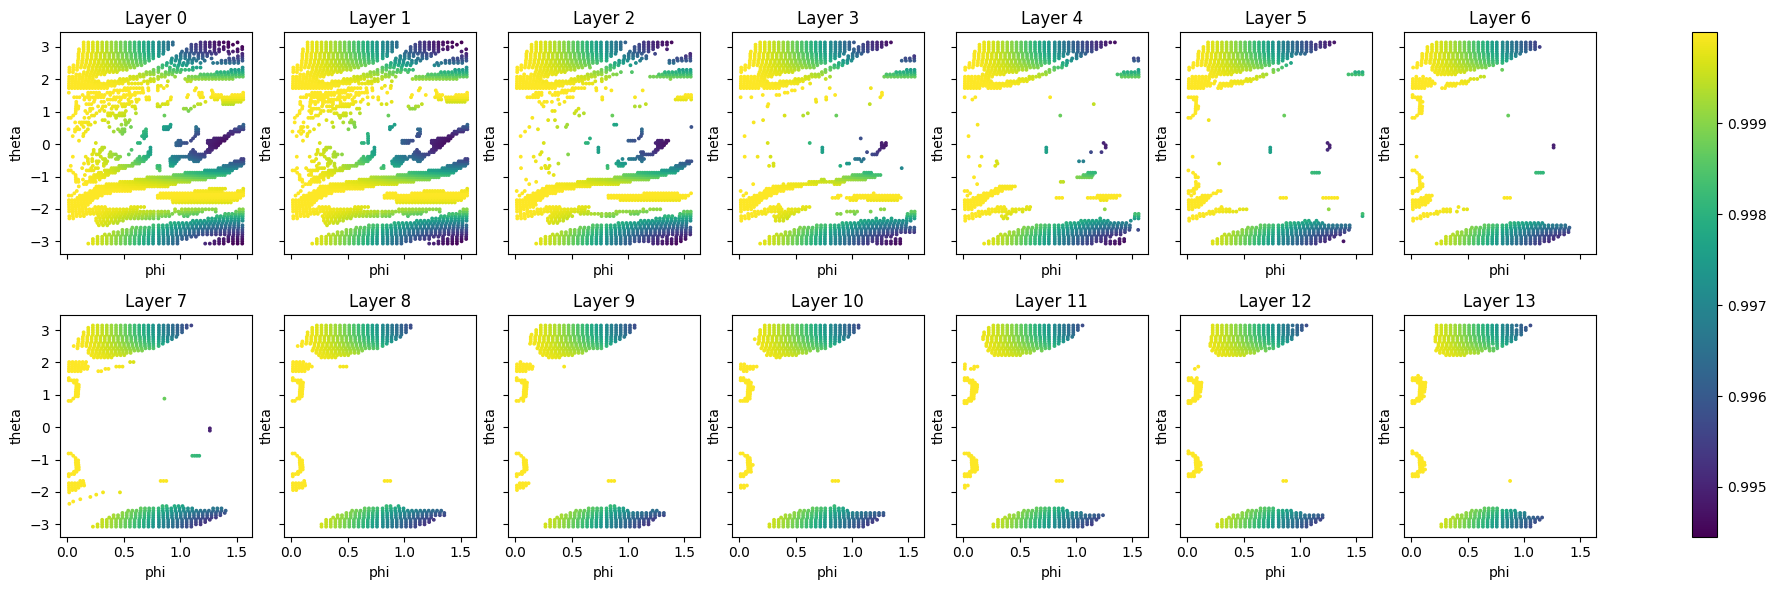

In [13]:
R = np.sqrt(d_x6[:,0]**2 + d_x6[:,1]**2)
r = R - 0.3048
x = d_x6[:, 0]
y = d_x6[:, 1]
z = d_x6[:, 2]
rho = np.arctan2(r,z)

rho2 = np.sqrt(r**2 +z**2)


unique_rho2 = np.unique(np.round(rho2, 4))


r_centers = np.array([0.1021, 0.1037, 0.1053, 0.1069, 0.1085, 0.1101, 0.1117, 0.1133, 0.1148, 0.1164,
 0.118,  0.1196, 0.1212, 0.1228])

layers = np.argmin(np.abs(rho2[:, None] - r_centers[None, :]), axis=1)

phi = np.arctan2(y, x)
theta = np.arctan2(z, r)

fig, axs = plt.subplots(2, 7, figsize=(20, 6), sharex=True, sharey=True)
axs = axs.ravel()
vmin = np.min(diff)
vmax = np.max(diff)
for i in range(14):
    mask = (layers == i)

    sc = axs[i].scatter(
        phi[mask],
        theta[mask],
        c=diff[mask],   
        s=3,
        cmap="viridis",
        #vmin=-0.07461337793549441,
        vmin = vmin,
        #vmax=0.07461337793549441
        vmax = vmax
    )

    axs[i].set_title(f"Layer {i}")
    axs[i].set_xlabel('phi')
    axs[i].set_ylabel('theta')

plt.title(f"Layer {i}")
plt.tight_layout()
cbar = fig.colorbar(
    sc,
    ax=axs
)

plt.show()



In [14]:
#test 1: single dipole field on single xyz point

xyz = np.array([[-3.46304289e-01, 4.24100439e-17, 6.59292724e-02]])

pts = np.array([[1, 0, 0]])

d1 = _Dipole(x=pts[0,0],y=pts[0,1],z=pts[0,2],phi=0,theta=-np.pi/2,m0=0.074625,rho=1)

dips = DipoleSet(d1,NFP=1,sym=False)

B1 = dips.compute_magnetic_field(xyz, basis="xyz")
print(B1)

[[-6.07243663e-09  2.87276962e-25  4.46591405e-10]]


In [15]:
#test 2: single dipole B field on multiple xyz points

xyz1 = np.array([
    [3.672430046730771891e-01, 1.804149191946202366e-02 ,-4.279128264492406590e-04],
    [3.606249223999399289e-01, 1.771636638586763374e-02 ,4.028189331275212892e-02],
    [3.450541587100184326e-01, 1.695142381727698586e-02 ,6.677472080911270313e-02],
    [3.304354795806324629e-01, 1.623325416385959508e-02 ,7.429125106456956062e-02],
    [3.225517124166451532e-01, 1.584594951877693267e-02 ,6.907924405246436417e-02],
    [3.193504215559995751e-01, 1.568868018359763014e-02 ,5.770305847785165559e-02],
    [3.180144602400148401e-01, 1.562304861272942672e-02 ,4.149271199638970842e-02],
    [3.183778442110363205e-01 ,1.564090052248243157e-02 ,2.187785147734789062e-02],
    [3.192287765408717837e-01 ,1.568270414721424297e-02 ,1.980150377923352734e-03],
    [3.193474360526021849e-01 ,1.568853351522073863e-02, -1.714977085638523524e-02]
])

pts = np.array([[1, 0, 0]])

d1 = _Dipole(x=pts[0,0],y=pts[0,1],z=pts[0,2],phi=0,theta=-np.pi/2,m0=0.074625,rho=1)

dips = DipoleSet(d1,NFP=1,sym=False)

B1 = dips.compute_magnetic_field(xyz1, basis="xyz")
print(B1)

[[-5.87684187e-08  2.51447560e-09 -5.96389902e-11]
 [-5.62971426e-08  2.34545127e-09  5.33287785e-09]
 [-5.13974492e-08  2.00651745e-09  7.90403472e-09]
 [-4.78422945e-08  1.75116233e-09  8.01416887e-09]
 [-4.64605048e-08  1.63908130e-09  7.14545361e-09]
 [-4.62505017e-08  1.60527630e-09  5.90421572e-09]
 [-4.64612629e-08  1.59989549e-09  4.24910683e-09]
 [-4.69089992e-08  1.61585973e-09  2.26019845e-09]
 [-4.72289690e-08  1.63243754e-09  2.06116993e-10]
 [-4.71649354e-08  1.63162616e-09 -1.78359658e-09]]


In [20]:
#test 3: multiple dipole B field on single xyz point
# i think i broke this....

pts = np.array([[1, 0, 0],[0,1,0],[0,0,0],[-1,0,0]])
d1 = _Dipole(x=pts[0,0],y=pts[0,1],z=pts[0,2],phi=np.pi,theta=np.pi/2,m0=0.074625,rho=1)
d2 = _Dipole(x=pts[1,0],y=pts[1,1],z=pts[1,2],phi=-np.pi/2,theta=np.pi/2,m0=0.074625,rho=1)
d3 = _Dipole(x=pts[2,0],y=pts[2,1],z=pts[2,2],phi=0,theta=np.pi,m0=0.074625,rho=1)
d4 = _Dipole(x=pts[3,0],y=pts[3,1],z=pts[3,2],phi=0,theta=np.pi/2,m0=0.074625,rho=1)
dips3 = DipoleSet(d1,d2,d3,d4,NFP=1,sym=False)
B3 = dips3.compute_magnetic_field(xyz, basis="xyz")
print(B3)

[[ 1.33858394e-07 -1.04441747e-08  1.61895596e-07]]


In [22]:
pts = np.array([[1, 0, 0],[0,1,0],[0,0,0],[-1,0,0]])
d1 = _Dipole(x=pts[0,0],y=pts[0,1],z=pts[0,2],phi=np.pi,theta=np.pi/2,m0=0.074625,rho=1)
d2 = _Dipole(x=pts[1,0],y=pts[1,1],z=pts[1,2],phi=-np.pi/2,theta=np.pi/2,m0=0.074625,rho=1)
d3 = _Dipole(x=pts[2,0],y=pts[2,1],z=pts[2,2],phi=0,theta=np.pi,m0=0.074625,rho=1)
d4 = _Dipole(x=pts[3,0],y=pts[3,1],z=pts[3,2],phi=0,theta=np.pi/2,m0=0.074625,rho=1)
dips4 = DipoleSet(d1,d2,d3,d4,NFP=1,sym=False)
xyz1 = np.array([
    [3.672430046730771891e-01, 1.804149191946202366e-02 ,-4.279128264492406590e-04],
    [3.606249223999399289e-01, 1.771636638586763374e-02 ,4.028189331275212892e-02],
    [3.450541587100184326e-01, 1.695142381727698586e-02 ,6.677472080911270313e-02],
    [3.304354795806324629e-01, 1.623325416385959508e-02 ,7.429125106456956062e-02],
    [3.225517124166451532e-01, 1.584594951877693267e-02 ,6.907924405246436417e-02],
    [3.193504215559995751e-01, 1.568868018359763014e-02 ,5.770305847785165559e-02],
    [3.180144602400148401e-01, 1.562304861272942672e-02 ,4.149271199638970842e-02],
    [3.183778442110363205e-01 ,1.564090052248243157e-02 ,2.187785147734789062e-02],
    [3.192287765408717837e-01 ,1.568270414721424297e-02 ,1.980150377923352734e-03],
    [3.193474360526021849e-01 ,1.568853351522073863e-02, -1.714977085638523524e-02]
])
B4 = dips4.compute_magnetic_field(xyz1, basis="xyz")
print(B3)


[[-4.60338893e-08 -7.91271901e-09  1.50054417e-07]
 [-9.54782406e-08 -1.07202011e-08  1.56187255e-07]
 [-1.34826191e-07 -1.34637070e-08  1.62335399e-07]
 [-1.58218409e-07 -1.53031325e-08  1.73742143e-07]
 [-1.61153314e-07 -1.58088515e-08  1.88904984e-07]
 [-1.47858217e-07 -1.53118839e-08  2.04388662e-07]
 [-1.20626939e-07 -1.40503999e-08  2.19457277e-07]
 [-8.13201558e-08 -1.21167488e-08  2.28393674e-07]
 [-3.90448186e-08 -1.00068532e-08  2.28782096e-07]
 [ 1.68534620e-09 -7.99753727e-09  2.23142698e-07]]


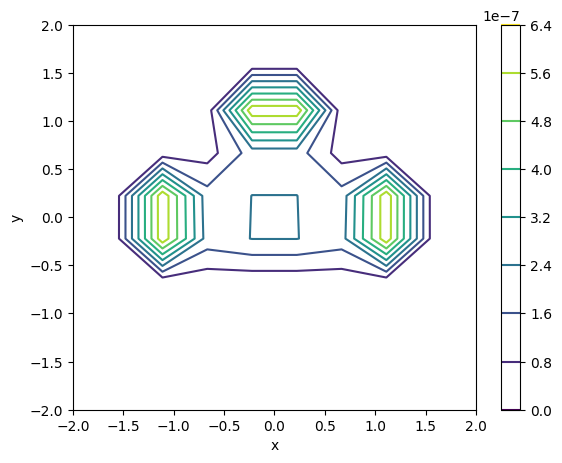

In [18]:
# graphing fields from test 3
Nb = 10
xlin =np.linspace(-2,2,Nb)
ylin =np.linspace(-2,2,Nb)

X,Y = np.meshgrid(xlin,ylin)
Z = np.zeros_like(X)

xyz_grid = np.column_stack([
    X.ravel(),
    Y.ravel(),
    Z.ravel(),
])

B_grid = dips3.compute_magnetic_field(xyz_grid, basis="xyz")

magB = np.linalg.norm(B_grid, axis=1)
magB = magB.reshape(X.shape)

plt.figure(figsize=(6.5,5))
plt.xlabel("x")
plt.ylabel("y")
plt.contour(X,Y,magB)
plt.colorbar()

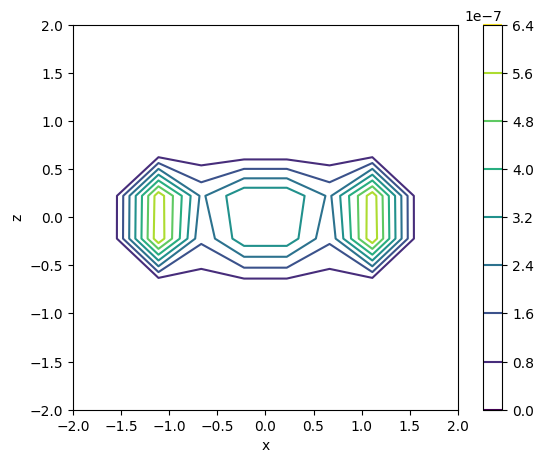

In [19]:
# graphing fields from test 3, from another angle (looking down from z axis)
Nb = 10
xlin = np.linspace(-2, 2, Nb)
zlin = np.linspace(-2, 2, Nb)

X, Z = np.meshgrid(xlin, zlin)
Y = np.zeros_like(X)   # fixed y = 0 plane

xyz_grid = np.column_stack([
    X.ravel(),
    Y.ravel(),
    Z.ravel(),
])

B_grid = dips3.compute_magnetic_field(xyz_grid, basis="xyz")

magB = np.linalg.norm(B_grid, axis=1).reshape(X.shape)

plt.figure(figsize=(6.5, 5))
plt.contour(X, Z, magB)

plt.xlabel("x")
plt.ylabel("z")
plt.colorbar()

plt.gca().set_aspect('equal')
plt.show()

In [ ]:
g, dat = DipoleSet.calc_g(one_period,eq)

In [ ]:
coilset = load('tf_coils_desc.h5')

In [ ]:

print(coilset)

In [ ]:
coilset.compute_magnetic_field(xyz,basis = 'xyz')

In [ ]:
plotpoints = pv.Plotter()
cloud1 = pv.PolyData(dat.reshape(-1, 3))
plotpoints.add_points(
    cloud1,
    #    scalars="values",
    point_size=8,
    render_points_as_spheres=True,
    cmap="viridis",
    color = 'red'
)
plotpoints.show()